In [1]:

# SECTION 1 — Imports & Helpers

import numpy as np
import time
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit.library import real_amplitudes
from qiskit.quantum_info import SparsePauliOp, Statevector 
from scipy.optimize import minimize

# ── Amplitude-encode a real vector |v> into a quantum circuit ──
def amplitude_encode(vec):
    """Returns a QuantumCircuit that initialises |vec> (normalised)."""
    v = np.array(vec, dtype=float) # Convert the input vec to a NumPy float array.
    n = v / (np.linalg.norm(v) + 1e-30) # Normalise the vector to unit length. The tiny 1e-30 prevents divide-by-zero if the vector is all zeros.
    n_qubits = int(np.ceil(np.log2(len(n))))
    n_qubits = max(n_qubits, 1)
    padded = np.zeros(2**n_qubits)
    padded[:len(n)] = n
    padded /= (np.linalg.norm(padded) + 1e-30)
    qc = QuantumCircuit(n_qubits)
    qc.initialize(padded.tolist())
    return qc

# ── Pauli decompose a square matrix ──
def pauli_decompose(M): # Decomposes a matrix M into a sum of weighted Pauli operators: M = Σᵢ cᵢ Pᵢ.
    # quantum computers can only apply Pauli operators, not arbitrary matrices.
    """Return SparsePauliOp representation of matrix M (must be power-of-2 size)."""
    return SparsePauliOp.from_operator(M)

print('Imports OK')

Imports OK


In [2]:
# SECTION 2 — VQLS Quantum Linear Solver

# Minimises  C(θ) = 1 - |<b|A|ψ(θ)>|² / (||A|ψ(θ)>||² · <b|b>)
# core quantum algorithm that replaces the classical np.linalg.solve

def vqls_solve(J, b, n_layers=2, verbose=False):
    # takes Jacobian J,mismatch vector b, no. of ansatz layers, verbosity flag. Returns the classical update vector x that solves J·x = b.
    """
    Quantum linear solve:  J x = b  →  returns x (classical vector).

    Steps
    1. Pad J to power-of-2 size and Pauli-decompose:  A = Σᵢ cᵢ Pᵢ
    2. Encode b into |b> circuit
    3. Build variational ansatz |ψ(θ)>
    4. Minimise VQLS cost with COBYLA
    cost=0 when A|ψ(θ)⟩ is parallel to |b⟩, meaning |ψ(θ)⟩ is proportional to the solution x = A⁻¹b.
    5. Read out <ψ(θ)| as classical update vector
    """
    # Calculate the number of qubits needed
    n = len(b)
    n_qubits = int(np.ceil(np.log2(n)))
    n_qubits = max(n_qubits, 1)

    # 1. Pad J to power-of-2 and Pauli-decompose
    size = 2**n_qubits
    J_pad = np.eye(size)
    J_pad[:n, :n] = J
    pauli_J = pauli_decompose(J_pad) # Decompose the padded Jacobian into Pauli operators. This is the quantum representation of the matrix.

    # 2. |b> circuit
    b_circ = amplitude_encode(b)

    # 3. Ansatz
    ansatz = real_amplitudes(n_qubits, reps=n_layers, entanglement='linear')
    n_params = ansatz.num_parameters

    # 4. Cost function (statevector-based, no hardware noise)
    def cost(theta):
        bound = ansatz.assign_parameters(theta)
        sv = Statevector(bound)
        psi = sv.data[:n]
        A_psi = J @ psi
        b_hat = b / (np.linalg.norm(b) + 1e-30)
        numerator   = abs(np.dot(b_hat.conj(), A_psi))**2
        denominator = np.dot(A_psi.conj(), A_psi).real + 1e-30
        return 1.0 - numerator / denominator

    theta0 = np.random.uniform(-np.pi, np.pi, n_params)
    res = minimize(cost, theta0, method='COBYLA',
                   options={'maxiter': 300, 'rhobeg': 0.5}) # un the COBYLA optimizer (a gradient-free method, suitable for quantum circuits) for up to 300 iterations with step size 0.5.

    if verbose:
        print(f'VQLS cost={res.fun:.6f}  iters={res.nfev}')

    # 5. Extract solution vector
    bound_final = ansatz.assign_parameters(res.x)
    sv_final = Statevector(bound_final)
    psi_final = sv_final.data[:n].real

    # Scale back (quantum gives direction, classical gives magnitude)
    A_psi = J @ psi_final
    scale = np.dot(A_psi, b) / (np.dot(A_psi, A_psi) + 1e-30) # Quantum amplitude encoding only preserves direction (unit norm). Use a least-squares projection to recover the correct magnitude: scale = ⟨A·ψ, b⟩ / ⟨A·ψ, A·ψ⟩. Return the correctly scaled solution vector.
    return psi_final * scale

print('VQLS solver ready')

VQLS solver ready


In [3]:
# SECTION 3 — System Data & Y-Bus 
# Example
# Bus 1 → Slack, Bus 2 → PQ, Bus 3 → PV
# INPUT SECTION with only liplang solver
# eg- Z12 = 0.02+0.04j
# Z13 = 0.01+0.03j
# Z23 = 0.0125+0.025j
# P2 = -190
# Q2 = -250
# P3 = 380
# V1 = 1.05
# V3 = 1.04
# Tolerance = 1e-6
# Solution 
#  V2     = 0.989727 pu
#  delta2 = 1.5463°
#  delta3 = 3.4268°

def get_user_input(prompt, default):
    try:
        val = input(f"{prompt} [default={default}]: ")
        if not val.strip():
            return float(default)
        return float(val)
    except:
        return float(default)

print("Enter System Data (Power in MW/MVAr will be converted to pu)")
BASE_MVA = 100.0

# 1. Bus 1 data (Slack)
V1 = get_user_input("Bus 1 (Slack) Voltage V1 (pu)", 1.05)
d1_deg = get_user_input("Bus 1 (Slack) Angle delta1 (deg)", 0.0)
d1_rad = np.radians(d1_deg)

# 2. Bus 2 data (PQ Load)
P2_mw = get_user_input("Bus 2 (PQ) Real Power P2 (MW, use -ve for load)", -190.0)
Q2_mvar = get_user_input("Bus 2 (PQ) Reactive Power Q2 (MVAr, use -ve for load)", -250.0)
P2_sch = P2_mw / BASE_MVA
Q2_sch = Q2_mvar / BASE_MVA

# 3. Bus 3 data (PV Gen)
V3_fixed = get_user_input("Bus 3 (PV) Voltage V3 (pu)", 1.04)
P3_mw = get_user_input("Bus 3 (PV) Real Power P3 (MW, use +ve for gen)", 380.0)
P3_sch = P3_mw / BASE_MVA

print("Enter line impedances (R + jX):")
Z12 = complex(input("Z12 (e.g. 0.02+0.04j): "))
Z13 = complex(input("Z13 (e.g. 0.01+0.03j): "))
Z23 = complex(input("Z23 (e.g. 0.0125+0.025j): "))

y12 = 1.0 / Z12
y13 = 1.0 / Z13
y23 = 1.0 / Z23

Y = np.zeros((3, 3), dtype=complex)
Y[0, 0] = y12 + y13
Y[1, 1] = y12 + y23
Y[2, 2] = y13 + y23
Y[0, 1] = Y[1, 0] = -y12
Y[0, 2] = Y[2, 0] = -y13
Y[1, 2] = Y[2, 1] = -y23

Ymag  = np.abs(Y)
Yangd = np.angle(Y)

print('\nY-Bus (magnitude):')
print(np.round(Ymag, 4))
print('\nY-Bus (angle, deg):')
print(np.round(np.degrees(Yangd), 2))
print('\nFinalized System data:')
print(f'  Slack: V1={V1:.4f} pu, delta1={d1_deg:.2f}°')
print(f'  Bus 2: P={P2_sch:.4f} pu, Q={Q2_sch:.4f} pu')
print(f'  Bus 3: P={P3_sch:.4f} pu, V={V3_fixed:.4f} pu')

Enter System Data (Power in MW/MVAr will be converted to pu)


Enter line impedances (R + jX):


ValueError: complex() arg is a malformed string

In [ ]:
# SECTION 4 — Mismatch & Jacobian Functions

# Unknowns: x = [δ₂ (rad), V₂ (pu), δ₃ (rad)]   ← all angles in RADIANS
# Bus 3 is PV → V₃ = V3_fixed pu fixed, only δ₃ unknown

def bus_power(V, d_rad):
    """Compute P_i, Q_i for all 3 buses. V[3] in pu, d_rad[3] in radians."""
    P = np.zeros(3)
    Q = np.zeros(3)
    for i in range(3):
        for k in range(3):
            P[i] += V[i] * V[k] * Ymag[i, k] * np.cos(Yangd[i, k] + d_rad[k] - d_rad[i])
            Q[i] -= V[i] * V[k] * Ymag[i, k] * np.sin(Yangd[i, k] + d_rad[k] - d_rad[i])
    return P, Q

def calc_mismatch(V2, d2_rad, d3_rad):
    """Returns mismatch vector [ΔP₂, ΔQ₂, ΔP₃].  Angles in radians."""
    V = np.array([V1, V2, V3_fixed])
    d = np.array([d1_rad, d2_rad, d3_rad])
    P, Q = bus_power(V, d)
    return np.array([P2_sch - P[1],
                     Q2_sch - Q[1],
                     P3_sch - P[2]])

def calc_jacobian(V2, d2_rad, d3_rad):
    """
    3×3 Jacobian  ∂[ΔP₂, ΔQ₂, ΔP₃] / ∂[δ₂ (rad), δ₃ (rad), V₂].
    """
    eps_angle = 1e-6
    eps_volt  = 1e-6
    eps_vec   = np.array([eps_angle, eps_angle, eps_volt])

    x0 = np.array([d2_rad, d3_rad, V2])

    J = np.zeros((3, 3))
    for j in range(3):
        xp = x0.copy(); xp[j] += eps_vec[j]
        xm = x0.copy(); xm[j] -= eps_vec[j]
        
        # Unpack as [d2, d3, V2]
        fp = calc_mismatch(xp[2], xp[0], xp[1])
        fm = calc_mismatch(xm[2], xm[0], xm[1])
        J[:, j] = (fp - fm) / (2 * eps_vec[j])
    return J

print('Mismatch & Jacobian functions ready')

Mismatch & Jacobian functions ready


In [ ]:
# SECTION 5 — Classical Newton-Raphson

# Solves using standard linalg.solve (Classical Implementation)

def classical_nr(tol=1e-6, max_iter=50):
    d2, V2, d3 = 0.0, 1.0, 0.0   # flat start (radians)
    history = [] 
    t0 = time.perf_counter() #  start timing.

    print("Running Classical NR...")
    print(f"{'Iter':<5} {'||mm||':<12} {'V2':<10} {'d2 (deg)':<10} {'d3 (deg)':<10}")
    
    for it in range(1, max_iter + 1):
        mm = calc_mismatch(V2, d2, d3) # power mismatch vector 
        err = np.linalg.norm(mm) # Measure its Euclidean norm as the convergence error.
        history.append((it, V2, np.degrees(d2), np.degrees(d3), err))
        
        print(f"{it:<5} {err:<12.6f} {V2:<10.4f} {np.degrees(d2):<10.4f} {np.degrees(d3):<10.4f}")
        
        if err < tol:
            print(f"\nConvergence Successful after {it} iterations.")
            break
            
        J = calc_jacobian(V2, d2, d3)
        dx = np.linalg.solve(J, mm)    # Classical linalg solver
        
        d2 -= dx[0]
        d3 -= dx[1]
        V2 -= dx[2]
    
    elapsed = time.perf_counter() - t0
    return V2, d2, d3, it, elapsed, history

V2c, d2c_rad, d3c_rad, it_c, t_c, hist_c = classical_nr()
d2c = np.degrees(d2c_rad)
d3c = np.degrees(d3c_rad)

print('=' * 55)
print('[Classical NR Results]')
print(f'  V2     = {V2c:.6f} pu')
print(f'  delta2 = {d2c:.4f}°')
print(f'  delta3 = {d3c:.4f}°')
print(f'  Time   = {t_c*1000:.1f} ms')
print('=' * 55)

Running Classical NR...
Iter  ||mm||       V2         d2 (deg)   d3 (deg)  
1     3.333652     1.0000     0.0000     0.0000    
2     0.038607     0.9903     1.5749     3.4639    
3     0.000027     0.9897     1.5463     3.4268    
4     0.000000     0.9897     1.5463     3.4268    

Convergence Successful after 4 iterations.
[Classical NR Results]
  V2     = 0.989727 pu
  delta2 = 1.5463°
  delta3 = 3.4268°
  Time   = 2.6 ms


In [ ]:
# SECTION 6 — Quantum Newton-Raphson (VQLS)


def quantum_nr(tol=1e-6, max_iter=50, verbose=True):
    d2, V2, d3 = 0.0, 1.0, 0.0   # flat start (radians)
    history = []
    pauli_history = [] # pauli_history — stores the Pauli decompositions of each Jacobian.
    t0 = time.perf_counter()

    for it in range(1, max_iter + 1):
        mm = calc_mismatch(V2, d2, d3)
        err = np.linalg.norm(mm)
        history.append((it, V2, np.degrees(d2), np.degrees(d3), err))
        if err < tol:
            break
        J = calc_jacobian(V2, d2, d3)

        # Quantum solve for Jx = mm
        # Using VQLS on A = J.T@J and b = J.T@mm for symmetry
        A = J.T @ J
        b = J.T @ mm
        
        if verbose:
            print(f'  Iter {it:2d}  ||mm||={err:.4f}  → VQLS...', end=' ')

        # Padded for Pauli decompose (3x3 -> 4x4)
        J_pad = np.eye(4)
        J_pad[:3, :3] = J
        pauli_J = pauli_decompose(J_pad)
        pauli_history.append(pauli_J)

        dx = vqls_solve(A, b)

        if verbose:
            print('done')

        d2 -= dx[0]
        d3 -= dx[1]
        V2 -= dx[2]

    elapsed = time.perf_counter() - t0
    return V2, d2, d3, it, elapsed, history, pauli_history

print('Running Quantum NR (VQLS)...')
V2q, d2q_rad, d3q_rad, it_q, t_q, hist_q, pauli_q = quantum_nr(verbose=True)
d2q = np.degrees(d2q_rad)
d3q = np.degrees(d3q_rad)

print('=' * 55)
print('[Quantum NR Results]')
print(f'  V2     = {V2q:.6f} pu')
print(f'  delta2 = {d2q:.4f}°')
print(f'  delta3 = {d3q:.4f}°')
print(f'  Time   = {t_q*1000:.1f} ms')
print('=' * 55)

Running Quantum NR (VQLS)...
  Iter  1  ||mm||=3.3337  → VQLS... done
  Iter  2  ||mm||=0.0385  → VQLS... done
  Iter  3  ||mm||=0.0003  → VQLS... done
[Quantum NR Results]
  V2     = 0.989727 pu
  delta2 = 1.5463°
  delta3 = 3.4268°
  Time   = 1552.7 ms



Method           V2 (pu)      d2 (°)       d3 (°)       Iters    Time (ms)
Classical NR     0.989727     1.5463       3.4268       4        2.6
Quantum NR       0.989727     1.5463       3.4268       4        1552.7

System Configuration: P2=-1.9 pu, Q2=-2.5 pu, P3=3.8 pu, V3=1.04 pu


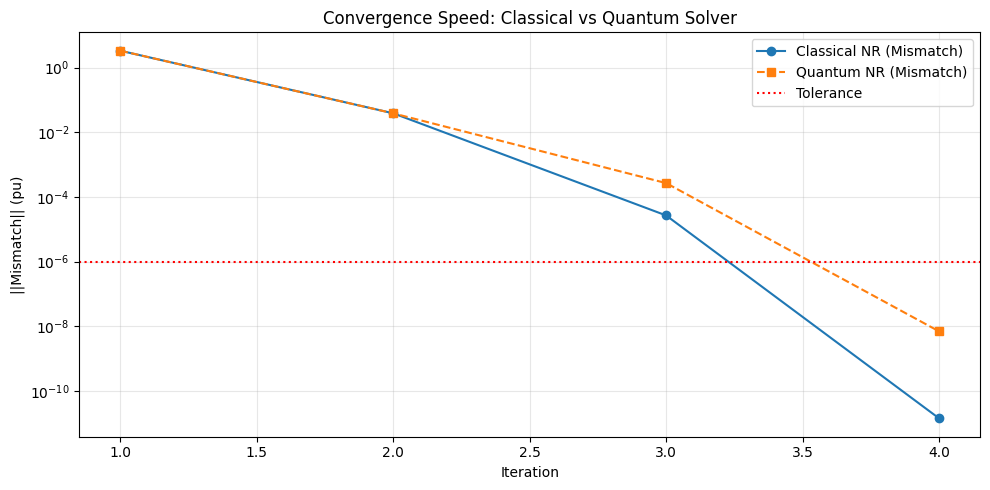

In [ ]:
# SECTION 7 — Results Comparison & Visualization

print('\n' + '=' * 70)
print(f'{"Method":<16} {"V2 (pu)":<12} {"d2 (°)":<12} {"d3 (°)":<12} {"Iters":<8} {"Time (ms)"}')
print('=' * 70)
print(f'{"Classical NR":<16} {V2c:<12.6f} {d2c:<12.4f} {d3c:<12.4f} {it_c:<8} {t_c*1000:.1f}')
print(f'{"Quantum NR":<16} {V2q:<12.6f} {d2q:<12.4f} {d3q:<12.4f} {it_q:<8} {t_q*1000:.1f}')
print('=' * 70)

print(f"\nSystem Configuration: P2={P2_sch} pu, Q2={Q2_sch} pu, P3={P3_sch} pu, V3={V3_fixed} pu")

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy([h[0] for h in hist_c], [h[4] for h in hist_c], 'o-', label='Classical NR (Mismatch)')
ax.semilogy([h[0] for h in hist_q], [h[4] for h in hist_q], 's--', label='Quantum NR (Mismatch)')
ax.axhline(1e-6, color='red', linestyle=':', label='Tolerance')
ax.set_xlabel('Iteration')
ax.set_ylabel('||Mismatch|| (pu)')
ax.set_title('Convergence Speed: Classical vs Quantum Solver')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()  
